# Intercept vs. shift: what each estimator actually measures

The `Intercept` analysis in `G_matrix.py` regresses each subject's within-block
crossnobis distances on the **leave-one-out group-mean** distances of the *same*
chords, separately for the trained and untrained blocks, and reads off:

- **`intercept`** — the subject's predicted distance where the *group* distance is 0
  ("residual distance where the group is flat").
- **`shift = mean(M_subj) - mean(M_group)`** — how far training raises the subject's
  *average* distance above the group ("push-up").
- **`slope`** — multiplicative scaling; **`r`** — shape agreement.

**Claim under test:** because the group mean is itself a noisy estimate, the
subject-vs-group slope is attenuated below 1, which forces the **raw intercept to be
positive even with no training effect at all**. `shift` does not have this problem, and
the **trained - untrained contrast** cancels the attenuation for both estimators.

We simulate distance matrices with a *known* ground truth so we can see exactly when each
estimator is unbiased and when it misleads. (We simulate the distances directly, abstracting
the G -> `G_to_dist` step; the statistical point is identical.)

## Generative model
- 8 chords with a fixed **intrinsic** geometry `D_true`, shared by everyone (training-free).
- Each subject randomly assigns 4 chords to *trained*, 4 to *untrained* (as in the study).
- Training modifies the distances **among that subject's trained chords**: `D * scale + offset`.
  `offset=0, scale=1` is the null (no training effect).
- Symmetric Gaussian measurement noise (crossnobis is unbiased, so it may go negative).

Because assignment is random, the trained and untrained blocks share the **same expectation
at the group level** — which is what makes the trained-vs-untrained contrast meaningful.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sb


def reorder(M, order):
    # permute rows & cols of a matrix onto `order`
    return M[np.ix_(order, order)]


def simulate_once(n_subj=12, n_train=4, n_untrain=4, offset=0.0, scale=1.0,
                  noise=0.5, base=(0.1, 1.0), seed=0):
    # per-subject distance matrices with a known training effect.
    # returns mats (n_subj, 8, 8), is_trained (n_subj, 8) bool, D_true (8, 8)
    rng    = np.random.default_rng(seed)
    n_cond = n_train + n_untrain
    iu     = np.triu_indices(n_cond, k=1)

    D_true       = np.zeros((n_cond, n_cond))                 # intrinsic, training-free geometry
    D_true[iu]   = rng.uniform(*base, size=iu[0].size)
    D_true      += D_true.T

    mats, is_trained = [], []
    for _ in range(n_subj):
        trained = rng.choice(n_cond, size=n_train, replace=False)   # random per subject
        mask    = np.zeros(n_cond, bool); mask[trained] = True
        tt      = np.outer(mask, mask)                        # trained-trained pairs

        D       = D_true.copy()
        D[tt]   = D[tt] * scale + offset                      # training reshapes the trained block
        E       = np.zeros((n_cond, n_cond))                  # symmetric measurement noise
        E[iu]   = rng.normal(0, noise, size=iu[0].size)
        E      += E.T
        D      += E
        np.fill_diagonal(D, 0)

        mats.append(D); is_trained.append(mask)
    return np.array(mats), np.array(is_trained), D_true


def analyze(mats, is_trained, leave_one_out=True):
    # per-subject slope / intercept / shift for the trained and untrained blocks,
    # mirroring Intercept.dataframe: reorder to subject i's order, take the (LOO)
    # group mean, regress subject-on-group
    n_subj, n_cond, _ = mats.shape
    n_train           = int(is_trained[0].sum())
    blocks            = {'trained': slice(0, n_train), 'untrained': slice(n_train, n_cond)}

    rows = []
    for i in range(n_subj):
        order   = np.concatenate([np.where(is_trained[i])[0], np.where(~is_trained[i])[0]])
        M_subj  = reorder(mats[i], order)
        keep    = [j for j in range(n_subj) if not (leave_one_out and j == i)]
        M_group = np.mean([reorder(mats[j], order) for j in keep], axis=0)

        for chord, sl in blocks.items():
            iu = np.triu_indices(sl.stop - sl.start, k=1)
            s  = M_subj[sl, sl][iu]      # this subject's block distances
            g  = M_group[sl, sl][iu]     # group-mean block distances (same chords)
            m  = linregress(g, s)
            rows.append({'sn': i, 'chord': chord, 'slope': m.slope,
                         'intercept': m.intercept, 'r': m.rvalue,
                         'shift': s.mean() - g.mean()})
    return pd.DataFrame(rows)


order_x = ['trained', 'untrained', 'trained-untrained']


def run(n_rep=300, n_subj=12, offset=0.0, scale=1.0, noise=0.5,
        base=(0.1, 1.0), leave_one_out=True, seed0=0):
    # repeat the experiment n_rep times; return the across-subject group statistic
    # per block and the trained-untrained contrast for every repetition
    recs = []
    for rep in range(n_rep):
        mats, is_tr, _ = simulate_once(n_subj=n_subj, offset=offset, scale=scale,
                                       noise=noise, base=base, seed=seed0 + rep)
        g = analyze(mats, is_tr, leave_one_out).groupby('chord')[['slope', 'intercept', 'shift']].mean()
        for est in ['slope', 'intercept', 'shift']:
            recs.append({'rep': rep, 'chord': 'trained',           'est': est, 'value': g.loc['trained', est]})
            recs.append({'rep': rep, 'chord': 'untrained',         'est': est, 'value': g.loc['untrained', est]})
            recs.append({'rep': rep, 'chord': 'trained-untrained', 'est': est, 'value': g.loc['trained', est] - g.loc['untrained', est]})
    return pd.DataFrame(recs)


def show(res, title):
    # boxplots of the three estimators across trained / untrained / contrast; also
    # return the table of expected (mean-over-reps) values
    fig, axs = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    for ax, est in zip(axs, ['intercept', 'shift', 'slope']):
        sb.boxplot(res[res.est == est], x='chord', y='value', order=order_x, ax=ax)
        ax.axhline(0, color='k', lw=.8, ls=':')
        ax.set_title(est); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
    fig.suptitle(title)
    plt.show()
    return res.groupby(['est', 'chord']).value.mean().unstack('chord')[order_x].round(3)

## Scenario A - no training effect (the null)

`offset = 0`, `scale = 1`. Every estimator *should* be 0.

Watch: the **intercept** for trained *and* untrained sits **above 0** (~0.11-0.13) because
regression dilution attenuates the slope (~0.77). But **shift** is 0, and the
**trained-untrained contrast** is ~0 for both estimators — the bias is common to both blocks
and cancels in the contrast. So *testing intercept != 0 per block would give false positives;
the contrast would not.*

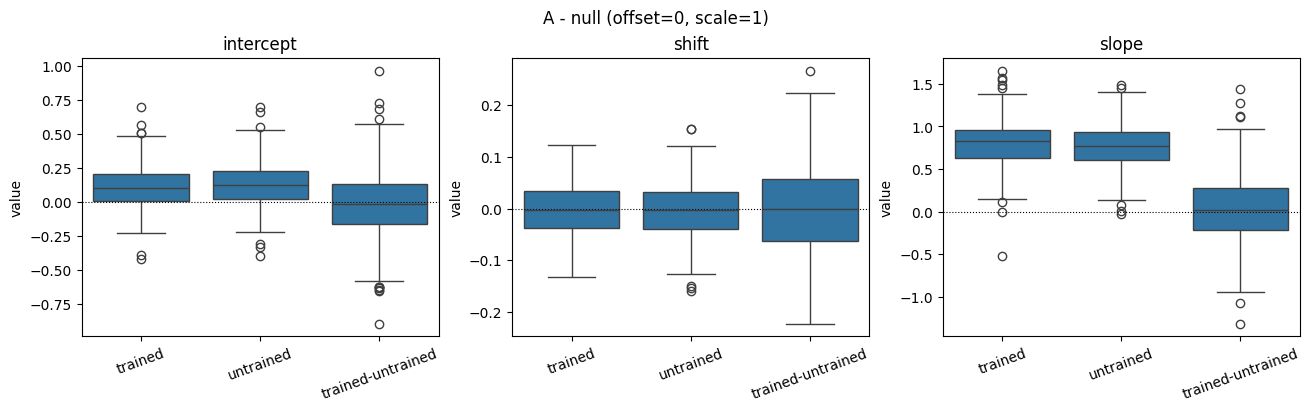

chord,trained,untrained,trained-untrained
est,,,
intercept,0.110,0.129,-0.019
shift,-0.002,-0.002,-0.000
slope,0.793,0.761,0.033


In [2]:
res_null = run(offset=0.0, scale=1.0)
show(res_null, 'A - null (offset=0, scale=1)')

## Scenario B - additive training effect

`offset = 0.3` on the trained block. True push-up: trained = 0.3, untrained = 0.

Watch the **shift** column: trained is only ~0.23 and untrained is slightly **negative**
(~-0.07) — not because the effect is wrong, but because the group mean is itself partly
trained (any chord pair is trained for ~21% of subjects), so each *per-block* estimate is
contaminated. Yet the **trained-untrained contrast** lands on **0.30 exactly** for `shift`
(algebraically `c(1-p) - (-pc) = c` for any overlap `p`) and ~0.27 for the intercept.
The contrast is the clean readout; `shift`'s contrast is exact.

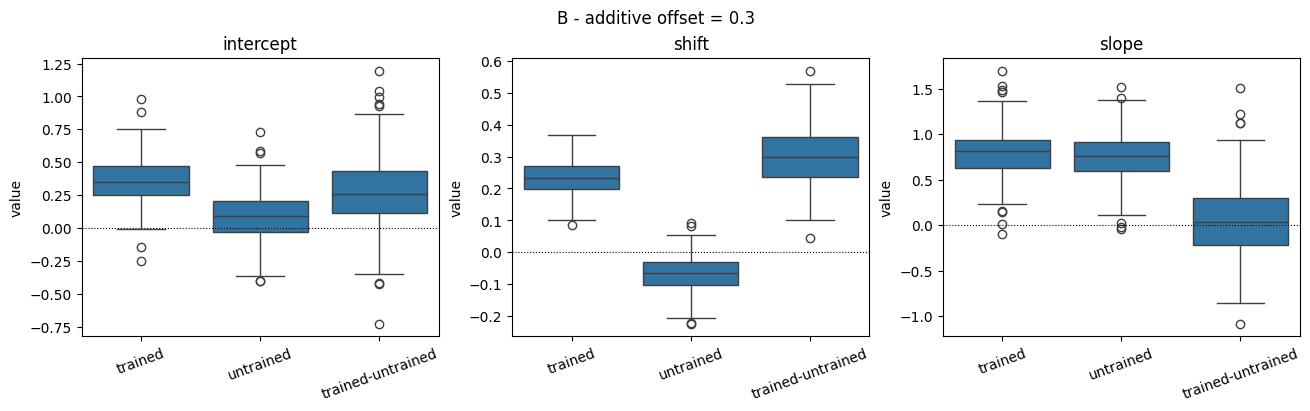

chord,trained,untrained,trained-untrained
est,,,
intercept,0.362,0.090,0.272
shift,0.233,-0.066,0.299
slope,0.789,0.745,0.044


In [3]:
res_add = run(offset=0.3, scale=1.0)
show(res_add, 'B - additive offset = 0.3')

## Scenario C - multiplicative effect (the intercept's blind spot)

`scale = 1.6`, `offset = 0`. Training *scales up* the trained distances — a real increase in
average dissimilarity with **no additive offset**.

Watch: the trained **intercept** barely moves and its **contrast is ~0.04** — if you had
tested "intercept != 0" you would have **missed this training effect**. Meanwhile `shift`
(contrast ~0.33) and `slope` (contrast ~0.46) both flag it clearly. Level effects and scaling
effects need different estimators; keep `slope`/`r` as separate readouts.

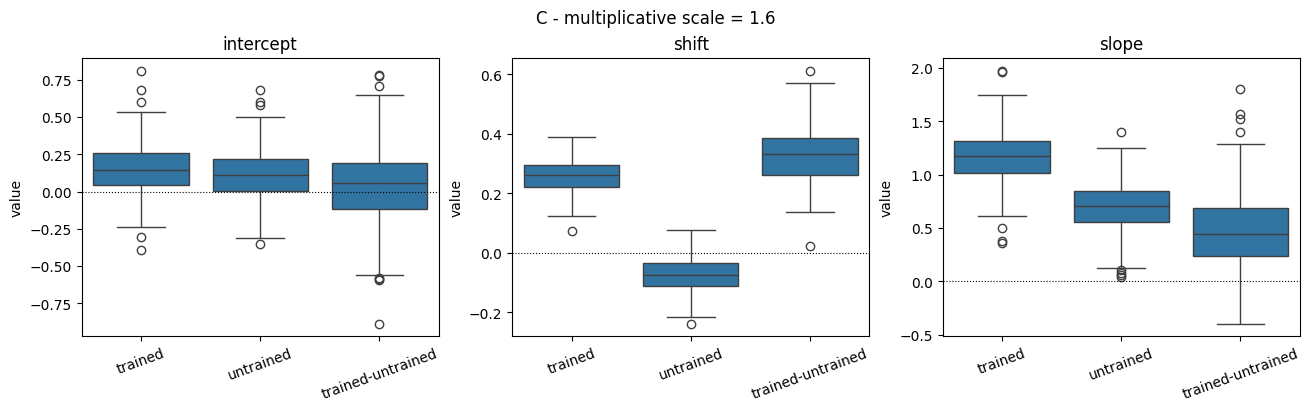

chord,trained,untrained,trained-untrained
est,,,
intercept,0.157,0.117,0.040
shift,0.259,-0.073,0.332
slope,1.160,0.696,0.464


In [4]:
res_mul = run(offset=0.0, scale=1.6)
show(res_mul, 'C - multiplicative scale = 1.6')

## Scenario D - leave-one-out vs. leaving the subject in

Under the null, leaving the subject **in** the group mean pushes slope->1 and intercept->0,
so it looks *cleaner* than LOO — but only because the subject is being regressed partly on
themselves (circularity). On a **real** effect that same self-inclusion leaks the subject's
own training into the reference and **dilutes** the contrast (~0.27 vs 0.30 with LOO).

So: the raw intercept's null bias is a symptom of doing LOO honestly. The fix is not to drop
LOO (that reintroduces circularity) but to read the effect off `shift` and the contrast,
which are robust either way.

null, subject left IN the group mean (intercept bias gone, but via circularity):


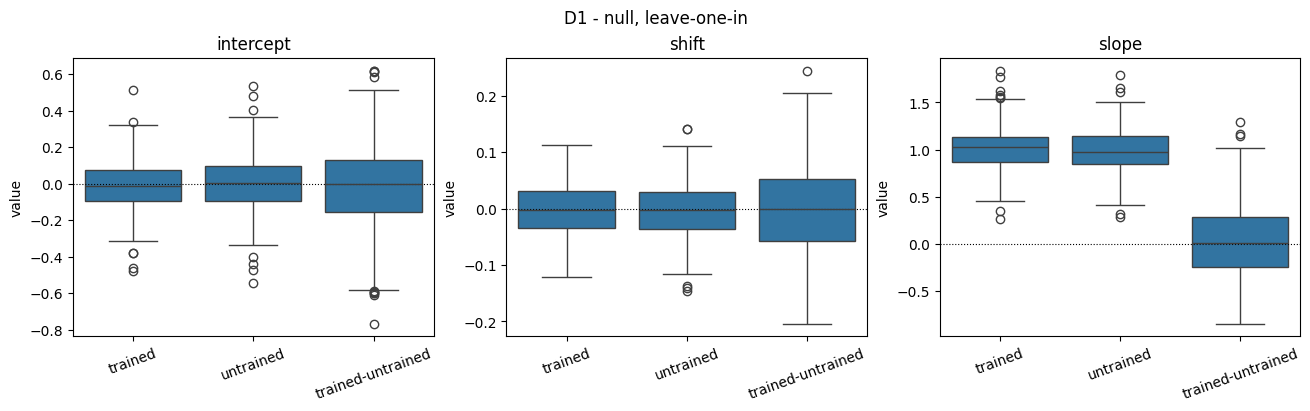

chord,trained,untrained,trained-untrained
est,,,
intercept,-0.013,0.004,-0.017
shift,-0.002,-0.002,-0.000
slope,1.015,0.989,0.026


additive 0.3, subject left IN (contrast diluted vs the LOO version in B):


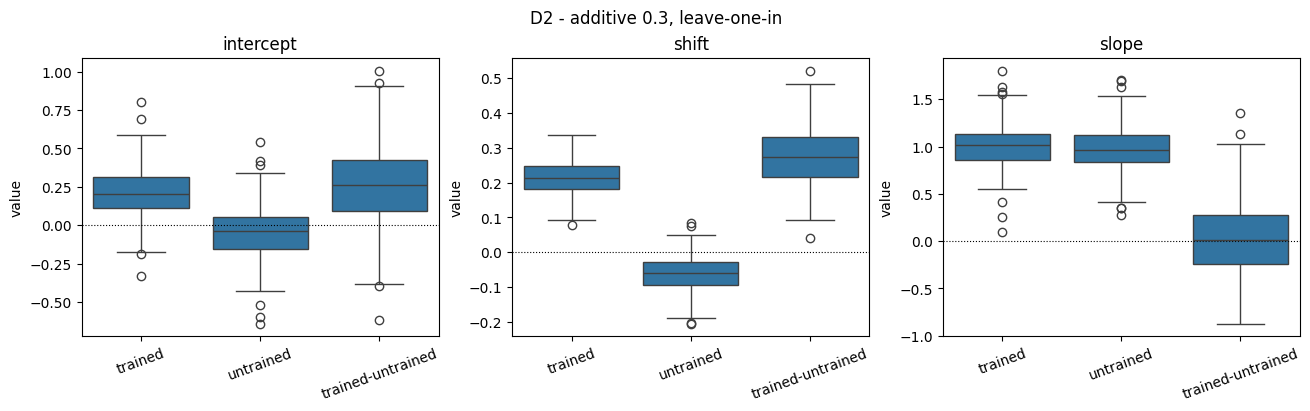

chord,trained,untrained,trained-untrained
est,,,
intercept,0.209,-0.045,0.254
shift,0.214,-0.061,0.274
slope,1.003,0.975,0.028


In [5]:
res_loi_null = run(offset=0.0, scale=1.0, leave_one_out=False)
print('null, subject left IN the group mean (intercept bias gone, but via circularity):')
display(show(res_loi_null, 'D1 - null, leave-one-in'))

res_loi_add = run(offset=0.3, scale=1.0, leave_one_out=False)
print('additive 0.3, subject left IN (contrast diluted vs the LOO version in B):')
show(res_loi_add, 'D2 - additive 0.3, leave-one-in')

## Takeaways for the `Intercept` analysis

- **Do not test `intercept != 0` per block as "training raised distances."** It is biased
  positive under the null (A) and blind to purely multiplicative effects (C).
- **For the average-dissimilarity question, use `shift = mean(M_subj) - mean(M_group)`** — 0
  under the null, recovers the additive effect (A, B).
- **For "trained vs. untrained," use the contrast.** It cancels the common attenuation *and*
  the chord-overlap contamination, and for `shift` it is exactly unbiased for the true offset
  (A, B) — this is the comparison the randomized design was built for.
- **Keep `slope` (scaling) and `r` (shape) as separate readouts** (C).
- **Leave-one-out is right** (already in `G_matrix.py`); leaving the subject in only *looks*
  cleaner because of circularity (D).

Tune `noise`, `n_subj`, `base`, `offset`, `scale` in `run(...)` to watch the biases grow and
shrink — e.g. `run(offset=0.0, noise=0.8)` roughly doubles the null intercept bias.